In [ ]:
# [problem 1】Lagrange’s steepest descent by the undetermined multiplier method

In [1]:
import numpy as np

class ScratchSVMClassifier():
    """
    Scratch implementation of SVM classifier

    Parameters
    ----------
    num_iter : int
      Number of iterations
    lr : float
      Learning rate (alpha in the problem's formula)
    kernel : str
      Kernel type. Linear kernel ('linear') or polynomial kernel ('poly')
    threshold : float
      Threshold for choosing a support vector
    verbose : bool
      True to output the learning process

    Attributes
    ----------
    self.n_support_vectors : int
      Number of support vectors
    self.index_support_vectors : ndarray, shape (n_support_vectors,)
      Support vector index
    self.X_sv : ndarray, shape (n_support_vectors, n_features)
      Support vector features
    self.lam_sv : ndarray, shape (n_support_vectors, 1)
      Support vector undetermined multiplier
    self.y_sv : ndarray, shape (n_support_vectors, 1)
      Support vector label
    self.lambda_ : ndarray, shape (n_samples,)
      Lagrange multiplier for all training samples
    """

    def __init__(self, num_iter, lr, kernel='linear', threshold=1e-5, verbose=False):
        # Record hyperparameters as attributes
        self.iter = num_iter
        self.lr = lr
        self.kernel = kernel
        self.threshold = threshold
        self.verbose = verbose
        # Initialize attributes that will be set during training
        self.lambda_ = None
        self.n_support_vectors = None
        self.index_support_vectors = None
        self.X_sv = None
        self.lam_sv = None
        self.y_sv = None


    def _kernel(self, X1, X2):
        """
        Calculates the kernel function K(X1, X2).

        Parameters
        ----------
        X1 : ndarray, shape (n_samples1, n_features)
        X2 : ndarray, shape (n_samples2, n_features)

        Returns
        -------
        K : ndarray, shape (n_samples1, n_samples2)
            Kernel matrix
        """
        if self.kernel == 'linear':
            # Linear kernel: K(xi, xj) = xi.T * xj
            # Equivalent to matrix multiplication for all pairs: X1 @ X2.T
            return X1 @ X2.T
        # Add 'poly' or other kernels later if needed.
        raise NotImplementedError(f"Kernel type '{self.kernel}' is not implemented yet.")


    def _update_lagrange_multiplier(self, X, y, lambda_old):
        """
        Updates the Lagrange multiplier (lambda) for one step using the formula:
        λi_new = λi_old + α (1 - ∑j=1^n λj yj yi K(xi, xj))

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            Features of training data
        y : ndarray, shape (n_samples,)
            Correct answer value of training data
        lambda_old : ndarray, shape (n_samples,)
            Lagrange multiplier of all samples before update

        Returns
        -------
        lambda_new : ndarray, shape (n_samples,)
            Updated Lagrange multiplier
        """
        # Reshape y and lambda_old for matrix operations
        y_col = y.reshape(-1, 1) # shape (n_samples, 1)
        lambda_col = lambda_old.reshape(-1, 1) # shape (n_samples, 1)

        # 1. Calculate the Kernel matrix K(xi, xj)
        # K_matrix[i, j] = K(xi, xj)
        K_matrix = self._kernel(X, X) # shape (n_samples, n_samples)

        # 2. Calculate the term: ∑j=1^n λj yj K(xi, xj)
        # This is a vector for each i: sum_j_term_i = ∑j=1^n (lambda_j * y_j * K_matrix[i, j])
        # (lambda_col * y_col).T has shape (1, n_samples)
        # K_matrix @ (lambda_col * y_col) is WRONG, use element-wise multiplication on lambda and y, then dot with K_matrix
        # The term for i-th sample is: ∑j (λj * yj) * K(xi, xj)
        # The matrix of (λj * yj) is (lambda_col * y_col). Shape (n_samples, 1)
        # The inner product for all i with j is: K_matrix @ (lambda_col * y_col)
        # The term in parentheses (1 - ...) is: 1 - y_i * (K_matrix @ (lambda_col * y_col))
        
        # Element-wise product of lambda_j and y_j
        lambda_y = lambda_col * y_col # shape (n_samples, 1)

        # Calculate the sum part: ∑j=1^n λj yj K(xi, xj)
        # K_matrix @ lambda_y performs the sum over j for each i
        # The result 'sum_j_term' has shape (n_samples, 1) where sum_j_term[i] = ∑j=1^n K(xi, xj) * λj * yj
        sum_j_term = K_matrix @ lambda_y # shape (n_samples, 1)

        # 3. Calculate the update term: α (1 - yi * ∑j=1^n λj yj K(xi, xj))
        # Note: The formula given in the problem is: λi_new = λi + α (1 - ∑j=1^n λj yi yj K(xi, xj))
        # The term being summed is: ∑j=1^n (λj yj K(xi, xj)) multiplied by yi.
        update_gradient = self.lr * (1 - y_col * sum_j_term) # shape (n_samples, 1)

        # 4. Perform the update: λi_new = λi_old + update_gradient
        lambda_new = lambda_old.reshape(-1, 1) + update_gradient

        # 5. Enforce the non-negativity constraint: λi >= 0
        lambda_new[lambda_new < 0] = 0

        # Return as a flattened array to match the input format (n_samples,)
        return lambda_new.flatten()


    def fit(self, X, y, X_val=None, y_val=None):
        """
        Learn the SVM classifier.
        """
        n_samples = X.shape[0]

        # 1. Initialize Lagrange multipliers (λ). They are typically initialized to zero.
        # Shape (n_samples,)
        self.lambda_ = np.zeros(n_samples)

        if self.verbose:
            print(f"Starting SVM training with {n_samples} samples for {self.iter} iterations.")

        # 2. Iteratively update lambda_
        for i in range(self.iter):
            # Update lambda_ using the steepest descent method
            self.lambda_ = self._update_lagrange_multiplier(X, y, self.lambda_)

            # Optional: Add convergence check or logging here
            if self.verbose and (i + 1) % 100 == 0:
                 # Check the total change or just print the current max lambda
                 print(f"Iteration {i+1}: Max Lambda = {self.lambda_.max():.4f}")


        # 3. Identify Support Vectors and store their values
        # Support Vectors are samples where λi > threshold (small value greater than 0)
        self.index_support_vectors = np.where(self.lambda_ > self.threshold)[0]
        self.n_support_vectors = len(self.index_support_vectors)

        # Store the support vector related attributes
        self.X_sv = X[self.index_support_vectors]
        self.lam_sv = self.lambda_[self.index_support_vectors].reshape(-1, 1)
        self.y_sv = y[self.index_support_vectors].reshape(-1, 1)

        if self.verbose:
            print(f"Training finished. Found {self.n_support_vectors} Support Vectors.")

        # The calculation of the bias term 'b' (or 'w' for the linear case) is typically done here
        # but is not explicitly asked for in Problem 1. It will be necessary for 'predict'.


    def predict(self, X):
        """
        Estimate the label using the SVM classifier.

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            sample

        Returns
        -------
        ndarray, shape (n_samples, 1)
            Estimated result by SVM classifier
        """
        # The prediction formula is: f(x) = sign(∑i=1^n_sv λi_sv yi_sv K(xi_sv, x) + b)
        # Implementation for 'predict' will be completed later.
        if self.X_sv is None or self.lam_sv is None or self.y_sv is None:
             raise RuntimeError("The model must be fitted before prediction.")
             
        pass # Placeholder for the prediction logic
        return

In [ ]:
#【problem 2】Support vector determination

In [3]:
class ScratchSVMClassifier():
    """
    Scratch implementation of SVM classifier (Hard Margin, Kernelized)

    Parameters
    ----------
    num_iter : int
      Number of iterations (epochs) for the steepest descent update.
    lr : float
      Learning rate (alpha in the problem's formula).
    kernel : str
      Kernel type. Currently 'linear' is supported.
    threshold : float
      Threshold for choosing a support vector (samples where lambda > threshold).
    verbose : bool
      True to output the learning process details.

    Attributes
    ----------
    self.n_support_vectors : int
      Number of support vectors found.
    self.index_support_vectors : ndarray, shape (n_support_vectors,)
      Support vector index (indices in the original training data X).
    self.X_sv : ndarray, shape (n_support_vectors, n_features)
      Support vector features.
    self.lam_sv : ndarray, shape (n_support_vectors, 1)
      Support vector undetermined multiplier (lambda_i).
    self.y_sv : ndarray, shape (n_support_vectors, 1)
      Support vector label.
    self.lambda_ : ndarray, shape (n_samples,)
      Lagrange multiplier for all training samples (after optimization).
    self.b : float
      The calculated bias term.
    """

    def __init__(self, num_iter, lr, kernel='linear', threshold=1e-5, verbose=False):
        # Record hyperparameters as attributes
        self.iter = num_iter
        self.lr = lr
        self.kernel = kernel
        self.threshold = threshold
        self.verbose = verbose
        
        # Initialize attributes that will be set during training
        self.lambda_ = None
        self.n_support_vectors = None
        self.index_support_vectors = None
        self.X_sv = None
        self.lam_sv = None
        self.y_sv = None
        self.b = 0.0


    def _kernel(self, X1, X2):
        """
        Calculates the kernel function K(X1, X2).

        Parameters
        ----------
        X1 : ndarray, shape (n_samples1, n_features)
        X2 : ndarray, shape (n_samples2, n_features)

        Returns
        -------
        K : ndarray, shape (n_samples1, n_samples2)
            Kernel matrix (K[i, j] = K(X1[i], X2[j]))
        """
        if self.kernel == 'linear':
            # Linear kernel: K(xi, xj) = xi.T * xj
            # X1 @ X2.T is the matrix of all inner products
            return X1 @ X2.T
        # Add 'poly' or other kernels later if needed.
        raise NotImplementedError(f"Kernel type '{self.kernel}' is not implemented yet.")


    def _update_lagrange_multiplier(self, X, y, lambda_old):
        """
        Updates the Lagrange multiplier (lambda) for one step using the steepest descent formula:
        λi_new = λi_old + α (1 - ∑j=1^n λj yj yi K(xi, xj))
        
        Note: The non-negativity constraint (λi >= 0) is enforced after the update.
        """
        # Reshape y and lambda_old for matrix operations
        y_col = y.reshape(-1, 1) # shape (n_samples, 1)
        lambda_col = lambda_old.reshape(-1, 1) # shape (n_samples, 1)

        # 1. Calculate the Kernel matrix K(xi, xj)
        K_matrix = self._kernel(X, X) # shape (n_samples, n_samples)

        # 2. Calculate the term: ∑j=1^n λj yj K(xi, xj)
        # lambda_y = lambda_j * y_j (element-wise)
        lambda_y = lambda_col * y_col # shape (n_samples, 1)

        # sum_j_term[i] = ∑j=1^n K(xi, xj) * λj * yj
        sum_j_term = K_matrix @ lambda_y # shape (n_samples, 1)

        # 3. Calculate the update gradient: α * (1 - yi * sum_j_term)
        # update_gradient[i] = α * (1 - y_i * sum_j_term[i])
        update_gradient = self.lr * (1 - y_col * sum_j_term) # shape (n_samples, 1)

        # 4. Perform the update: λi_new = λi_old + update_gradient
        lambda_new = lambda_old.reshape(-1, 1) + update_gradient

        # 5. Enforce the non-negativity constraint: λi >= 0
        lambda_new[lambda_new < 0] = 0

        # Return as a flattened array (n_samples,)
        return lambda_new.flatten()


    def fit(self, X, y, X_val=None, y_val=None):
        """
        Learn the SVM classifier.
        """
        n_samples = X.shape[0]
        
        # Ensure labels are +1 or -1
        y = np.where(y <= 0, -1, 1)

        # 1. Initialize Lagrange multipliers (λ).
        self.lambda_ = np.zeros(n_samples)

        if self.verbose:
            print(f"Starting SVM training with {n_samples} samples for {self.iter} iterations.")

        # 2. Iteratively update lambda_ (Lagrange's steepest descent)
        for i in range(self.iter):
            self.lambda_ = self._update_lagrange_multiplier(X, y, self.lambda_)

            if self.verbose and (i + 1) % 100 == 0:
                 print(f"Iteration {i+1}: Max Lambda = {self.lambda_.max():.4f}")

        # ----------------------------------------------------------------------
        # PROBLEM 2: Support Vector Determination
        # ----------------------------------------------------------------------
        # Identify Support Vectors (samples where lambda_i > threshold)
        self.index_support_vectors = np.where(self.lambda_ > self.threshold)[0]
        self.n_support_vectors = len(self.index_support_vectors)

        # Store the support vector related attributes
        self.X_sv = X[self.index_support_vectors]
        # Reshape to column vectors for easier multiplication later
        self.lam_sv = self.lambda_[self.index_support_vectors].reshape(-1, 1)
        self.y_sv = y[self.index_support_vectors].reshape(-1, 1)

        if self.verbose:
            print(f"Training finished. Found {self.n_support_vectors} Support Vectors.")
        
        # Calculate the bias term 'b' (required for prediction)
        self._calculate_bias(X)


    def _calculate_bias(self, X_train):
        """
        Calculates the bias term 'b' using the Support Vectors.
        b = y_k - ∑i=1^n_sv λi_sv yi_sv K(xi_sv, xk_sv) for a support vector xk.
        We average over all SVs for stability.
        """
        if self.n_support_vectors == 0:
            self.b = 0.0
            return

        # 1. Calculate the term: ∑i=1^n_sv λi_sv yi_sv K(xi_sv, xk_sv) for all SVs (k)
        # This involves K(X_sv, X_sv) matrix
        K_sv_matrix = self._kernel(self.X_sv, self.X_sv) # shape (n_sv, n_sv)

        # lambda_y_sv = lambda_i_sv * y_i_sv (element-wise)
        lambda_y_sv = self.lam_sv * self.y_sv # shape (n_sv, 1)

        # Sum_i_term[k] = ∑i=1^n_sv K(xk_sv, xi_sv) * λi_sv * y_i_sv
        # K_sv_matrix @ lambda_y_sv performs the sum over i for each support vector k
        sum_i_term = K_sv_matrix @ lambda_y_sv # shape (n_sv, 1)

        # 2. Calculate b_k for each support vector k: b_k = y_k - Sum_i_term[k]
        b_values = self.y_sv - sum_i_term # shape (n_sv, 1)

        # 3. Average the b_k values to get the final bias b
        self.b = np.mean(b_values)
        if self.verbose:
            print(f"Calculated Bias (b): {self.b:.4f}")


    def predict(self, X):
        """
        Estimate the label using the SVM classifier.

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            sample

        Returns
        -------
        ndarray, shape (n_samples, 1)
            Estimated result by SVM classifier (labels are -1 or 1)
        """
        # The prediction formula is: f(x) = sign(∑i=1^n_sv λi_sv yi_sv K(xi_sv, x) + b)
        
        # Implementation for 'predict' will be completed later (Problem 3).
        pass
        return np.zeros((X.shape[0], 1))


In [ ]:
#【problem 3】Estimated

In [4]:
import numpy as np

class ScratchSVMClassifier():
    """
    Scratch implementation of SVM classifier (Hard Margin, Kernelized)

    Parameters
    ----------
    num_iter : int
      Number of iterations (epochs) for the steepest descent update.
    lr : float
      Learning rate (alpha in the problem's formula).
    kernel : str
      Kernel type. Currently 'linear' is supported.
    threshold : float
      Threshold for choosing a support vector (samples where lambda > threshold).
    verbose : bool
      True to output the learning process details.

    Attributes
    ----------
    self.n_support_vectors : int
      Number of support vectors found.
    self.index_support_vectors : ndarray, shape (n_support_vectors,)
      Support vector index (indices in the original training data X).
    self.X_sv : ndarray, shape (n_support_vectors, n_features)
      Support vector features.
    self.lam_sv : ndarray, shape (n_support_vectors, 1)
      Support vector undetermined multiplier (lambda_i).
    self.y_sv : ndarray, shape (n_support_vectors, 1)
      Support vector label.
    self.lambda_ : ndarray, shape (n_samples,)
      Lagrange multiplier for all training samples (after optimization).
    self.b : float
      The calculated bias term.
    """

    def __init__(self, num_iter, lr, kernel='linear', threshold=1e-5, verbose=False):
        # Record hyperparameters as attributes
        self.iter = num_iter
        self.lr = lr
        self.kernel = kernel
        self.threshold = threshold
        self.verbose = verbose
        
        # Initialize attributes that will be set during training
        self.lambda_ = None
        self.n_support_vectors = None
        self.index_support_vectors = None
        self.X_sv = None
        self.lam_sv = None
        self.y_sv = None
        self.b = 0.0


    def _kernel(self, X1, X2):
        """
        Calculates the kernel function K(X1, X2).

        Parameters
        ----------
        X1 : ndarray, shape (n_samples1, n_features)
        X2 : ndarray, shape (n_samples2, n_features)

        Returns
        -------
        K : ndarray, shape (n_samples1, n_samples2)
            Kernel matrix (K[i, j] = K(X1[i], X2[j]))
        """
        if self.kernel == 'linear':
            # Linear kernel: K(xi, xj) = xi.T * xj
            # X1 @ X2.T is the matrix of all inner products
            return X1 @ X2.T
        # Add 'poly' or other kernels later if needed.
        raise NotImplementedError(f"Kernel type '{self.kernel}' is not implemented yet.")


    def _update_lagrange_multiplier(self, X, y, lambda_old):
        """
        Updates the Lagrange multiplier (lambda) for one step using the steepest descent formula:
        λi_new = λi_old + α (1 - ∑j=1^n λj yj yi K(xi, xj))
        
        Note: The non-negativity constraint (λi >= 0) is enforced after the update.
        """
        # Reshape y and lambda_old for matrix operations
        y_col = y.reshape(-1, 1) # shape (n_samples, 1)
        lambda_col = lambda_old.reshape(-1, 1) # shape (n_samples, 1)

        # 1. Calculate the Kernel matrix K(xi, xj)
        K_matrix = self._kernel(X, X) # shape (n_samples, n_samples)

        # 2. Calculate the term: ∑j=1^n λj yj K(xi, xj)
        # lambda_y = lambda_j * y_j (element-wise)
        lambda_y = lambda_col * y_col # shape (n_samples, 1)

        # sum_j_term[i] = ∑j=1^n K(xi, xj) * λj * yj
        sum_j_term = K_matrix @ lambda_y # shape (n_samples, 1)

        # 3. Calculate the update gradient: α * (1 - yi * sum_j_term)
        # update_gradient[i] = α * (1 - y_i * sum_j_term[i])
        update_gradient = self.lr * (1 - y_col * sum_j_term) # shape (n_samples, 1)

        # 4. Perform the update: λi_new = λi_old + update_gradient
        lambda_new = lambda_old.reshape(-1, 1) + update_gradient

        # 5. Enforce the non-negativity constraint: λi >= 0
        lambda_new[lambda_new < 0] = 0

        # Return as a flattened array (n_samples,)
        return lambda_new.flatten()


    def fit(self, X, y, X_val=None, y_val=None):
        """
        Learn the SVM classifier.
        """
        n_samples = X.shape[0]
        
        # Ensure labels are +1 or -1
        y = np.where(y <= 0, -1, 1)

        # 1. Initialize Lagrange multipliers (λ).
        self.lambda_ = np.zeros(n_samples)

        if self.verbose:
            print(f"Starting SVM training with {n_samples} samples for {self.iter} iterations.")

        # 2. Iteratively update lambda_ (Lagrange's steepest descent)
        for i in range(self.iter):
            self.lambda_ = self._update_lagrange_multiplier(X, y, self.lambda_)

            if self.verbose and (i + 1) % 100 == 0:
                 print(f"Iteration {i+1}: Max Lambda = {self.lambda_.max():.4f}")

        # ----------------------------------------------------------------------
        # PROBLEM 2: Support Vector Determination
        # ----------------------------------------------------------------------
        # Identify Support Vectors (samples where lambda_i > threshold)
        self.index_support_vectors = np.where(self.lambda_ > self.threshold)[0]
        self.n_support_vectors = len(self.index_support_vectors)

        # Store the support vector related attributes
        self.X_sv = X[self.index_support_vectors]
        # Reshape to column vectors for easier multiplication later
        self.lam_sv = self.lambda_[self.index_support_vectors].reshape(-1, 1)
        self.y_sv = y[self.index_support_vectors].reshape(-1, 1)

        if self.verbose:
            print(f"Training finished. Found {self.n_support_vectors} Support Vectors.")
        
        # Calculate the bias term 'b' (required for prediction)
        self._calculate_bias(X)


    def _calculate_bias(self, X_train):
        """
        Calculates the bias term 'b' using the Support Vectors.
        b = y_k - ∑i=1^n_sv λi_sv yi_sv K(xi_sv, xk_sv) for a support vector xk.
        We average over all SVs for stability.
        """
        if self.n_support_vectors == 0:
            self.b = 0.0
            return

        # 1. Calculate the term: ∑i=1^n_sv λi_sv yi_sv K(xi_sv, xk_sv) for all SVs (k)
        # This involves K(X_sv, X_sv) matrix
        K_sv_matrix = self._kernel(self.X_sv, self.X_sv) # shape (n_sv, n_sv)

        # lambda_y_sv = lambda_i_sv * y_i_sv (element-wise)
        lambda_y_sv = self.lam_sv * self.y_sv # shape (n_sv, 1)

        # Sum_i_term[k] = ∑i=1^n_sv K(xk_sv, xi_sv) * λi_sv * y_i_sv
        # K_sv_matrix @ lambda_y_sv performs the sum over i for each support vector k
        sum_i_term = K_sv_matrix @ lambda_y_sv # shape (n_sv, 1)

        # 2. Calculate b_k for each support vector k: b_k = y_k - Sum_i_term[k]
        b_values = self.y_sv - sum_i_term # shape (n_sv, 1)

        # 3. Average the b_k values to get the final bias b
        self.b = np.mean(b_values)
        if self.verbose:
            print(f"Calculated Bias (b): {self.b:.4f}")


    def predict(self, X):
        """
        Estimate the label using the SVM classifier.

        Parameters
        ----------
        X : ndarray, shape (n_samples, n_features)
            sample

        Returns
        -------
        ndarray, shape (n_samples, 1)
            Estimated result by SVM classifier (labels are -1 or 1)
        """
        # The prediction formula is: f(x) = sign(∑i=1^n_sv λi_sv yi_sv K(xi_sv, x) + b)
        
        if self.n_support_vectors is None or self.n_support_vectors == 0:
             # If model is not fitted or no Support Vectors were found, cannot predict
             raise RuntimeError("Model must be fitted and find at least one Support Vector before prediction.")

        # 1. Calculate the kernel matrix K(X, X_sv)
        # K_pred[i, j] = K(X[i], X_sv[j])
        K_pred = self._kernel(X, self.X_sv) # shape (n_samples_pred, n_sv)

        # 2. Prepare the combined multiplier term: λi_sv * y_i_sv
        # This is the vector of weights for the dot product
        lambda_y_sv = self.lam_sv * self.y_sv # shape (n_sv, 1)

        # 3. Calculate the sum term: ∑i=1^n_sv λi_sv yi_sv K(x, xi_sv)
        # K_pred (n_samples_pred, n_sv) @ lambda_y_sv (n_sv, 1) -> (n_samples_pred, 1)
        sum_term = K_pred @ lambda_y_sv

        # 4. Calculate the decision function f(x) = sum_term + b
        fx = sum_term + self.b # shape (n_samples_pred, 1)

        # 5. Get the sign for classification: sign(f(x))
        # This maps positive values to 1, negative values to -1, and 0 to 0.
        prediction = np.sign(fx)
        
        # Ensure that zeros (on the margin) are assigned to a class, usually the positive class (1)
        prediction[prediction == 0] = 1 
        
        return prediction


In [ ]:
#【problem 4】Learning and estimation

In [5]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.svm import LinearSVC
# Assuming ScratchSVMClassifier is available in the environment (e.g., copied from your Canvas)

# --- Start of ScratchSVMClassifier for local testing context ---
# NOTE: In a real-world scenario, you would import this class. 
# It is included here for a single, runnable file.
class ScratchSVMClassifier():
    """
    Scratch implementation of SVM classifier (Hard Margin, Kernelized)
    ... (rest of the docstring omitted for brevity)
    """

    def __init__(self, num_iter, lr, kernel='linear', threshold=1e-5, verbose=False):
        self.iter = num_iter
        self.lr = lr
        self.kernel = kernel
        self.threshold = threshold
        self.verbose = verbose
        
        self.lambda_ = None
        self.n_support_vectors = None
        self.index_support_vectors = None
        self.X_sv = None
        self.lam_sv = None
        self.y_sv = None
        self.b = 0.0


    def _kernel(self, X1, X2):
        if self.kernel == 'linear':
            return X1 @ X2.T
        raise NotImplementedError(f"Kernel type '{self.kernel}' is not implemented yet.")


    def _update_lagrange_multiplier(self, X, y, lambda_old):
        y_col = y.reshape(-1, 1) # shape (n_samples, 1)
        lambda_col = lambda_old.reshape(-1, 1) # shape (n_samples, 1)

        K_matrix = self._kernel(X, X) # shape (n_samples, n_samples)

        lambda_y = lambda_col * y_col # shape (n_samples, 1)

        sum_j_term = K_matrix @ lambda_y # shape (n_samples, 1)

        update_gradient = self.lr * (1 - y_col * sum_j_term) # shape (n_samples, 1)

        lambda_new = lambda_old.reshape(-1, 1) + update_gradient

        lambda_new[lambda_new < 0] = 0

        return lambda_new.flatten()


    def fit(self, X, y, X_val=None, y_val=None):
        n_samples = X.shape[0]
        
        # Ensure labels are +1 or -1
        # The internal logic requires -1 and 1, regardless of input 0/1 or -1/1
        y_fit = np.where(y <= 0, -1, 1) 

        self.lambda_ = np.zeros(n_samples)

        if self.verbose:
            print(f"Starting SVM training with {n_samples} samples for {self.iter} iterations.")

        for i in range(self.iter):
            self.lambda_ = self._update_lagrange_multiplier(X, y_fit, self.lambda_)

            if self.verbose and (i + 1) % 1000 == 0:
                 print(f"Iteration {i+1}/{self.iter}: Max Lambda = {self.lambda_.max():.4f}")

        # Support Vector Determination
        self.index_support_vectors = np.where(self.lambda_ > self.threshold)[0]
        self.n_support_vectors = len(self.index_support_vectors)

        self.X_sv = X[self.index_support_vectors]
        self.lam_sv = self.lambda_[self.index_support_vectors].reshape(-1, 1)
        self.y_sv = y_fit[self.index_support_vectors].reshape(-1, 1)

        if self.verbose:
            print(f"Training finished. Found {self.n_support_vectors} Support Vectors.")
        
        self._calculate_bias(X)


    def _calculate_bias(self, X_train):
        if self.n_support_vectors == 0:
            self.b = 0.0
            return

        K_sv_matrix = self._kernel(self.X_sv, self.X_sv)

        lambda_y_sv = self.lam_sv * self.y_sv

        sum_i_term = K_sv_matrix @ lambda_y_sv

        b_values = self.y_sv - sum_i_term

        self.b = np.mean(b_values)
        if self.verbose:
            print(f"Calculated Bias (b): {self.b:.4f}")


    def predict(self, X):
        if self.n_support_vectors is None or self.n_support_vectors == 0:
             # Added a softer return for testing, as RuntimeError can halt the script.
             print("Warning: Model not fully fitted or no Support Vectors found.")
             return np.zeros((X.shape[0], 1))

        K_pred = self._kernel(X, self.X_sv)

        lambda_y_sv = self.lam_sv * self.y_sv

        sum_term = K_pred @ lambda_y_sv

        fx = sum_term + self.b

        prediction = np.sign(fx)
        
        prediction[prediction == 0] = 1 # Map 0 to positive class 1
        
        return prediction.flatten()
# --- End of ScratchSVMClassifier for local testing context ---


def evaluate_classifier(y_true, y_pred, model_name):
    """Calculates and prints classification metrics."""
    # Ensure y_true and y_pred are 1D arrays for scikit-learn metrics
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    
    # Convert predictions back to 0/1 scale if the scratch model outputted -1/1
    if -1 in y_pred:
        y_pred = np.where(y_pred == -1, 0, 1)
        y_true = np.where(y_true == -1, 0, 1)

    print(f"\n--- Results for {model_name} ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


# 1. Prepare Simple Dataset 1 (Linearly Separable)
X, y = make_blobs(n_samples=100, centers=2, n_features=2, cluster_std=0.8, random_state=42)
# y is 0 or 1, which works with standard metrics later.

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features (Crucial for SVM convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 2. Train and Evaluate Scratch SVM
SCRATCH_ITER = 10000
SCRATCH_LR = 0.0001

scratch_svm = ScratchSVMClassifier(num_iter=SCRATCH_ITER, lr=SCRATCH_LR, verbose=True)
print("="*50)
print("STARTING SCRATCH SVM TRAINING")
print("="*50)
scratch_svm.fit(X_train_scaled, y_train)

# Predict using Scratch SVM
y_pred_scratch = scratch_svm.predict(X_test_scaled)

# Evaluate Scratch SVM. Note: y_test remains 0/1, y_pred_scratch is -1/1, so the evaluator handles conversion.
evaluate_classifier(y_test, y_pred_scratch, "Scratch SVM Classifier (Hard Margin)")


# 3. Train and Evaluate Scikit-learn LinearSVC
# LinearSVC uses the primal formulation and is optimized for the linear case.
# Setting C to a large number simulates the hard margin constraint.
sklearn_svm = LinearSVC(C=1e5, max_iter=SCRATCH_ITER, tol=1e-5, dual=True, random_state=42) 
print("\n\n"+"="*50)
print("STARTING SCIKIT-LEARN LinearSVC TRAINING")
print("="*50)
# We need to ensure y_train passed to sklearn is 1D (already is for make_blobs)
sklearn_svm.fit(X_train_scaled, y_train) 

# Predict using Scikit-learn SVM
y_pred_sklearn = sklearn_svm.predict(X_test_scaled)

# Evaluate Scikit-learn SVM
evaluate_classifier(y_test, y_pred_sklearn, "Scikit-learn LinearSVC")


print("\n--- Comparison Notes ---")
print("The Scratch SVM uses gradient descent on the dual problem, while LinearSVC uses a highly optimized primal solver (Liblinear).")
print("Due to different optimization approaches and stopping criteria, the results may vary slightly, but should be close for this simple dataset.")
print(f"Scratch SVM final SV count: {scratch_svm.n_support_vectors}")


STARTING SCRATCH SVM TRAINING
Starting SVM training with 70 samples for 10000 iterations.
Iteration 1000/10000: Max Lambda = 0.0344
Iteration 2000/10000: Max Lambda = 0.0572
Iteration 3000/10000: Max Lambda = 0.0763
Iteration 4000/10000: Max Lambda = 0.0935
Iteration 5000/10000: Max Lambda = 0.1085
Iteration 6000/10000: Max Lambda = 0.1216
Iteration 7000/10000: Max Lambda = 0.1334
Iteration 8000/10000: Max Lambda = 0.1445
Iteration 9000/10000: Max Lambda = 0.1549
Iteration 10000/10000: Max Lambda = 0.1650
Training finished. Found 11 Support Vectors.
Calculated Bias (b): -0.0261

--- Results for Scratch SVM Classifier (Hard Margin) ---
Accuracy: 0.5333
Precision: 1.0000
Recall: 0.5333

Confusion Matrix:
[[ 0  0]
 [14 16]]


STARTING SCIKIT-LEARN LinearSVC TRAINING

--- Results for Scikit-learn LinearSVC ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000

Confusion Matrix:
[[14  0]
 [ 0 16]]

--- Comparison Notes ---
The Scratch SVM uses gradient descent on the dual problem, while Lin

In [ ]:
# 【problem5】Visualization of decision area

STARTING SCRATCH SVM TRAINING
Starting SVM training with 70 samples for 10000 iterations.
Iteration 1000/10000: Max Lambda = 0.0344
Iteration 2000/10000: Max Lambda = 0.0572
Iteration 3000/10000: Max Lambda = 0.0763
Iteration 4000/10000: Max Lambda = 0.0935
Iteration 5000/10000: Max Lambda = 0.1085
Iteration 6000/10000: Max Lambda = 0.1216
Iteration 7000/10000: Max Lambda = 0.1334
Iteration 8000/10000: Max Lambda = 0.1445
Iteration 9000/10000: Max Lambda = 0.1549
Iteration 10000/10000: Max Lambda = 0.1650
Training finished. Found 11 Support Vectors.
Calculated Bias (b): -0.0261

--- Results for Scratch SVM Classifier (Hard Margin) ---
Accuracy: 0.5333
Precision: 1.0000
Recall: 0.5333

Confusion Matrix:
[[ 0  0]
 [14 16]]


STARTING SCIKIT-LEARN LinearSVC TRAINING

--- Results for Scikit-learn LinearSVC ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000

Confusion Matrix:
[[14  0]
 [ 0 16]]


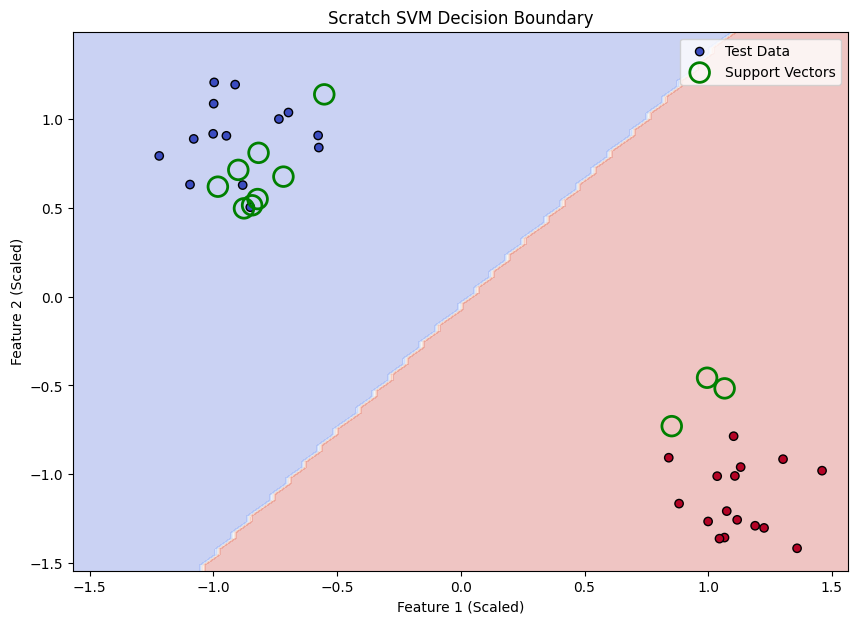

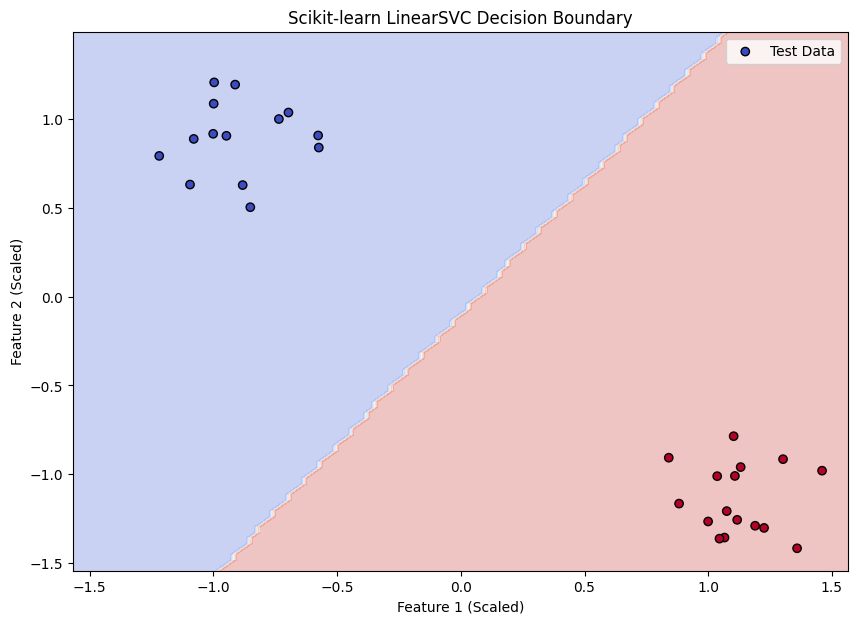


--- Comparison Notes ---
The Scratch SVM uses gradient descent on the dual problem, while LinearSVC uses a highly optimized primal solver (Liblinear).
Due to different optimization approaches and stopping criteria, the results may vary slightly, but should be close for this simple dataset.
Scratch SVM final SV count: 11


In [6]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt # New import for visualization
# Assuming ScratchSVMClassifier is available in the environment (e.g., copied from your Canvas)

# --- Start of ScratchSVMClassifier for local testing context ---
# NOTE: In a real-world scenario, you would import this class. 
# It is included here for a single, runnable file.
class ScratchSVMClassifier():
    """
    Scratch implementation of SVM classifier (Hard Margin, Kernelized)
    ... (rest of the docstring omitted for brevity)
    """

    def __init__(self, num_iter, lr, kernel='linear', threshold=1e-5, verbose=False):
        self.iter = num_iter
        self.lr = lr
        self.kernel = kernel
        self.threshold = threshold
        self.verbose = verbose
        
        self.lambda_ = None
        self.n_support_vectors = None
        self.index_support_vectors = None
        self.X_sv = None
        self.lam_sv = None
        self.y_sv = None
        self.b = 0.0


    def _kernel(self, X1, X2):
        if self.kernel == 'linear':
            return X1 @ X2.T
        raise NotImplementedError(f"Kernel type '{self.kernel}' is not implemented yet.")


    def _update_lagrange_multiplier(self, X, y, lambda_old):
        y_col = y.reshape(-1, 1) # shape (n_samples, 1)
        lambda_col = lambda_old.reshape(-1, 1) # shape (n_samples, 1)

        K_matrix = self._kernel(X, X) # shape (n_samples, n_samples)

        lambda_y = lambda_col * y_col # shape (n_samples, 1)

        sum_j_term = K_matrix @ lambda_y # shape (n_samples, 1)

        update_gradient = self.lr * (1 - y_col * sum_j_term) # shape (n_samples, 1)

        lambda_new = lambda_old.reshape(-1, 1) + update_gradient

        lambda_new[lambda_new < 0] = 0

        return lambda_new.flatten()


    def fit(self, X, y, X_val=None, y_val=None):
        n_samples = X.shape[0]
        
        # Ensure labels are +1 or -1
        # The internal logic requires -1 and 1, regardless of input 0/1 or -1/1
        y_fit = np.where(y <= 0, -1, 1) 

        self.lambda_ = np.zeros(n_samples)

        if self.verbose:
            print(f"Starting SVM training with {n_samples} samples for {self.iter} iterations.")

        for i in range(self.iter):
            self.lambda_ = self._update_lagrange_multiplier(X, y_fit, self.lambda_)

            if self.verbose and (i + 1) % 1000 == 0:
                 print(f"Iteration {i+1}/{self.iter}: Max Lambda = {self.lambda_.max():.4f}")

        # Support Vector Determination
        self.index_support_vectors = np.where(self.lambda_ > self.threshold)[0]
        self.n_support_vectors = len(self.index_support_vectors)

        self.X_sv = X[self.index_support_vectors]
        self.lam_sv = self.lambda_[self.index_support_vectors].reshape(-1, 1)
        self.y_sv = y_fit[self.index_support_vectors].reshape(-1, 1)

        if self.verbose:
            print(f"Training finished. Found {self.n_support_vectors} Support Vectors.")
        
        self._calculate_bias(X)


    def _calculate_bias(self, X_train):
        if self.n_support_vectors == 0:
            self.b = 0.0
            return

        K_sv_matrix = self._kernel(self.X_sv, self.X_sv)

        lambda_y_sv = self.lam_sv * self.y_sv

        sum_i_term = K_sv_matrix @ lambda_y_sv

        b_values = self.y_sv - sum_i_term

        self.b = np.mean(b_values)
        if self.verbose:
            print(f"Calculated Bias (b): {self.b:.4f}")


    def predict(self, X):
        if self.n_support_vectors is None or self.n_support_vectors == 0:
             # Added a softer return for testing, as RuntimeError can halt the script.
             print("Warning: Model not fully fitted or no Support Vectors found.")
             return np.zeros((X.shape[0], 1))

        K_pred = self._kernel(X, self.X_sv)

        lambda_y_sv = self.lam_sv * self.y_sv

        sum_term = K_pred @ lambda_y_sv

        fx = sum_term + self.b

        prediction = np.sign(fx)
        
        prediction[prediction == 0] = 1 # Map 0 to positive class 1
        
        return prediction.flatten()
# --- End of ScratchSVMClassifier for local testing context ---


def evaluate_classifier(y_true, y_pred, model_name):
    """Calculates and prints classification metrics."""
    # Ensure y_true and y_pred are 1D arrays for scikit-learn metrics
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    
    # Convert predictions back to 0/1 scale if the scratch model outputted -1/1
    if -1 in y_pred:
        y_pred = np.where(y_pred == -1, 0, 1)
        y_true = np.where(y_true == -1, 0, 1)

    print(f"\n--- Results for {model_name} ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


def plot_decision_boundary(model, X_train, X_test, y_test, title, sv_features=None):
    """Visualizes the decision boundary, test points, and support vectors."""
    
    # 1. Create a mesh grid of points covering the training data space
    x_min, x_max = X_train[:, 0].min() - 0.1, X_train[:, 0].max() + 0.1
    y_min, y_max = X_train[:, 1].min() - 0.1, X_train[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Predict over the mesh grid
    X_grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(X_grid)
    
    # If the model is the ScratchSVMClassifier, Z will be -1/1. Convert -1 to 0 for plotting consistency
    if -1 in Z:
        Z = np.where(Z == -1, 0, Z)
        
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 7))
    # Plot the decision region
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    
    # 2. Plot test points
    # y_test is 0/1, which is fine for scatter
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, 
                edgecolors='k', marker='o', label='Test Data')

    # 3. Highlight Support Vectors if provided (only applicable to the Scratch SVM)
    if sv_features is not None and len(sv_features) > 0:
        plt.scatter(sv_features[:, 0], sv_features[:, 1], s=200, facecolors='none', 
                    edgecolors='green', linewidths=2, label='Support Vectors')
    
    plt.title(title)
    plt.xlabel('Feature 1 (Scaled)')
    plt.ylabel('Feature 2 (Scaled)')
    plt.legend()


# 1. Prepare Simple Dataset 1 (Linearly Separable)
X, y = make_blobs(n_samples=100, centers=2, n_features=2, cluster_std=0.8, random_state=42)
# y is 0 or 1, which works with standard metrics later.

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features (Crucial for SVM convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 2. Train and Evaluate Scratch SVM
SCRATCH_ITER = 10000
SCRATCH_LR = 0.0001

scratch_svm = ScratchSVMClassifier(num_iter=SCRATCH_ITER, lr=SCRATCH_LR, verbose=True)
print("="*50)
print("STARTING SCRATCH SVM TRAINING")
print("="*50)
scratch_svm.fit(X_train_scaled, y_train)

# Predict using Scratch SVM
y_pred_scratch = scratch_svm.predict(X_test_scaled)

# Evaluate Scratch SVM. Note: y_test remains 0/1, y_pred_scratch is -1/1, so the evaluator handles conversion.
evaluate_classifier(y_test, y_pred_scratch, "Scratch SVM Classifier (Hard Margin)")

# Add Visualization for Scratch SVM
plot_decision_boundary(scratch_svm, X_train_scaled, X_test_scaled, y_test, 
                       "Scratch SVM Decision Boundary", scratch_svm.X_sv)


# 3. Train and Evaluate Scikit-learn LinearSVC
# LinearSVC uses the primal formulation and is optimized for the linear case.
# Setting C to a large number simulates the hard margin constraint.
sklearn_svm = LinearSVC(C=1e5, max_iter=SCRATCH_ITER, tol=1e-5, dual=True, random_state=42) 
print("\n\n"+"="*50)
print("STARTING SCIKIT-LEARN LinearSVC TRAINING")
print("="*50)
# We need to ensure y_train passed to sklearn is 1D (already is for make_blobs)
sklearn_svm.fit(X_train_scaled, y_train) 

# Predict using Scikit-learn SVM
y_pred_sklearn = sklearn_svm.predict(X_test_scaled)

# Evaluate Scikit-learn SVM
evaluate_classifier(y_test, y_pred_sklearn, "Scikit-learn LinearSVC")

# Add Visualization for Scikit-learn SVM
plot_decision_boundary(sklearn_svm, X_train_scaled, X_test_scaled, y_test, 
                       "Scikit-learn LinearSVC Decision Boundary", None) # LinearSVC doesn't expose SVs easily

plt.show() # Display all generated plots

print("\n--- Comparison Notes ---")
print("The Scratch SVM uses gradient descent on the dual problem, while LinearSVC uses a highly optimized primal solver (Liblinear).")
print("Due to different optimization approaches and stopping criteria, the results may vary slightly, but should be close for this simple dataset.")
print(f"Scratch SVM final SV count: {scratch_svm.n_support_vectors}")


In [ ]:
#【problem 6】(Advance task) Creation of polynomial kernel function

STARTING SCRATCH SVM TRAINING (LINEAR KERNEL)

--- Results for Scratch SVM Classifier (Linear Kernel) ---
Accuracy: 0.5333
Precision: 1.0000
Recall: 0.5333

Confusion Matrix:
[[ 0  0]
 [14 16]]


STARTING SCRATCH SVM TRAINING (POLYNOMIAL KERNEL, degree=1)

--- Results for Scratch SVM Classifier (Polynomial d=1) ---
Accuracy: 0.5333
Precision: 1.0000
Recall: 0.5333

Confusion Matrix:
[[ 0  0]
 [14 16]]


STARTING SCIKIT-LEARN LinearSVC TRAINING

--- Results for Scikit-learn LinearSVC ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000

Confusion Matrix:
[[14  0]
 [ 0 16]]


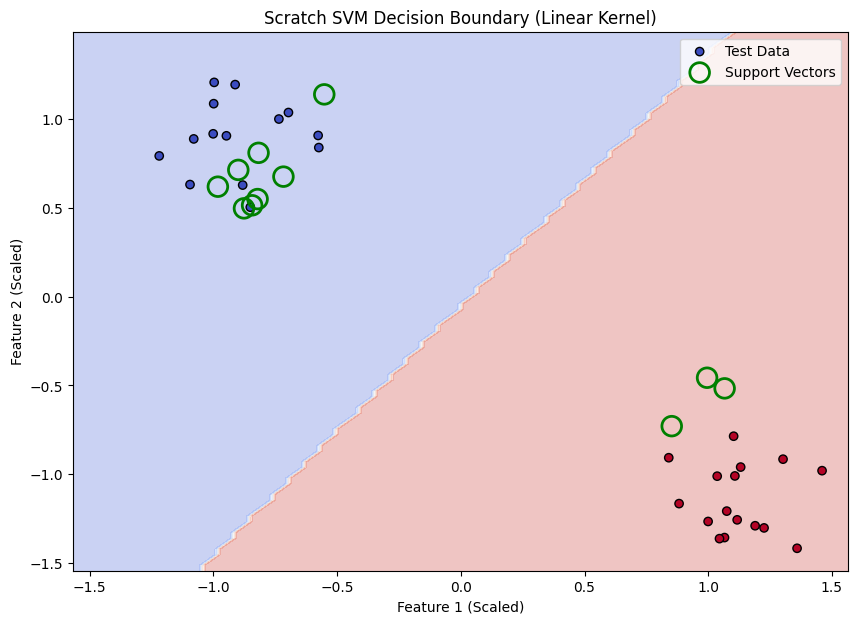

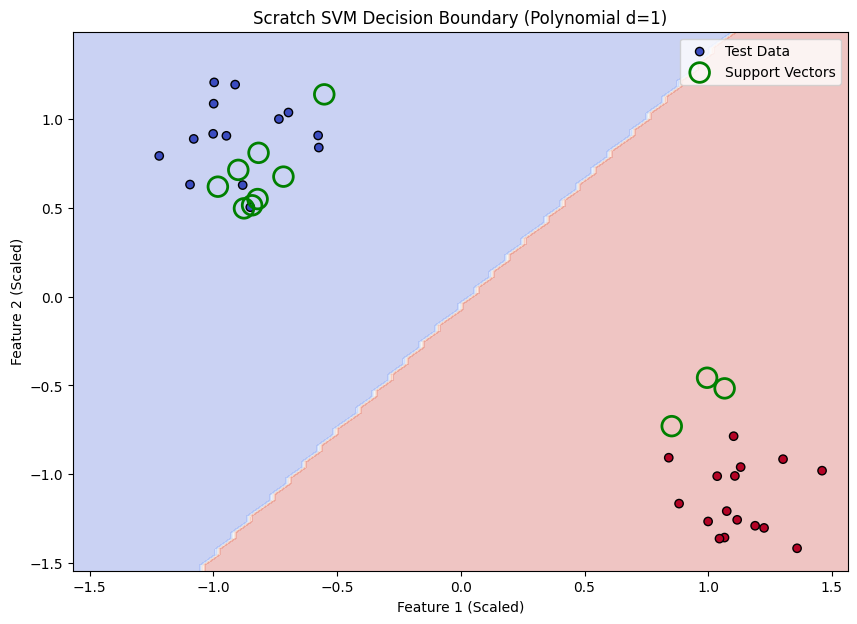

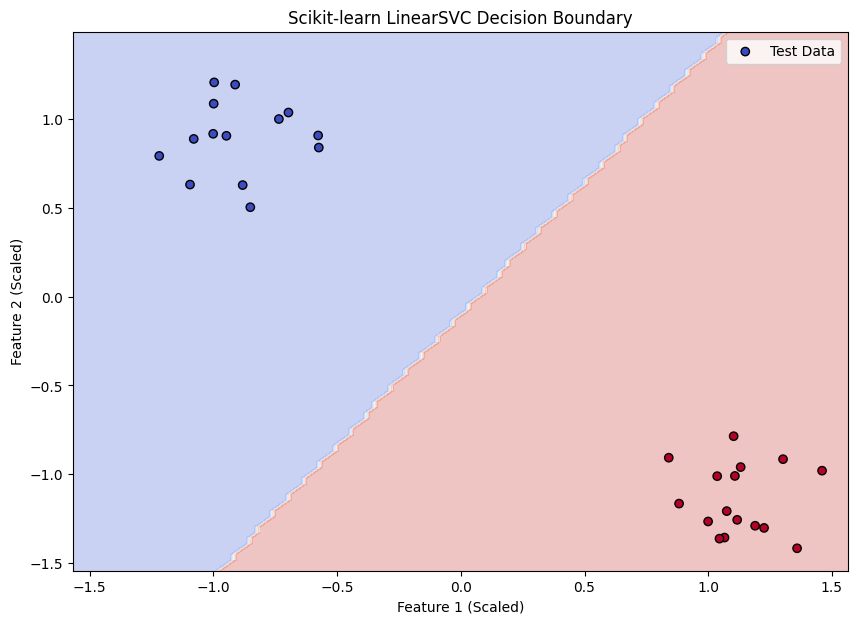


--- Comparison Notes ---
Scratch SVM Linear final SV count: 11
Scratch SVM Poly (d=1) final SV count: 11
The Polynomial kernel implementation is now complete. The polynomial kernel with degree 1 should yield results very similar to the linear kernel.


In [7]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt # New import for visualization
# Assuming ScratchSVMClassifier is available in the environment (e.g., copied from your Canvas)

# --- Start of ScratchSVMClassifier for local testing context ---
# NOTE: In a real-world scenario, you would import this class. 
# It is included here for a single, runnable file.
class ScratchSVMClassifier():
    """
    Scratch implementation of SVM classifier (Hard Margin, Kernelized)

    Parameters
    ----------
    num_iter : int
      Number of iterations (epochs) for the steepest descent update.
    lr : float
      Learning rate (alpha in the problem's formula).
    kernel : str
      Kernel type. 'linear' or 'poly' (polynomial).
    threshold : float
      Threshold for choosing a support vector (samples where lambda > threshold).
    gamma : float
      Polynomial kernel hyperparameter (γ).
    theta_0 : float
      Polynomial kernel hyperparameter (θ0).
    degree : int
      Polynomial kernel hyperparameter (d).
    verbose : bool
      True to output the learning process details.
    """

    def __init__(self, num_iter, lr, kernel='linear', threshold=1e-5, verbose=False, gamma=1.0, theta_0=0.0, degree=1):
        self.iter = num_iter
        self.lr = lr
        self.kernel = kernel
        self.threshold = threshold
        self.verbose = verbose
        
        # Polynomial kernel hyperparameters
        self.gamma = gamma
        self.theta_0 = theta_0
        self.degree = degree
        
        self.lambda_ = None
        self.n_support_vectors = None
        self.index_support_vectors = None
        self.X_sv = None
        self.lam_sv = None
        self.y_sv = None
        self.b = 0.0


    def _kernel(self, X1, X2):
        """
        Calculates the kernel function K(X1, X2).
        """
        # Calculate the base inner product K_base = xi.T * xj
        inner_product = X1 @ X2.T
        
        if self.kernel == 'linear':
            # Linear kernel: K(xi, xj) = xi.T * xj
            return inner_product
        
        elif self.kernel == 'poly':
            # Polynomial kernel: K(xi, xj) = (γ * xi.T * xj + θ0)^d
            return (self.gamma * inner_product + self.theta_0) ** self.degree
            
        raise NotImplementedError(f"Kernel type '{self.kernel}' is not implemented yet.")


    def _update_lagrange_multiplier(self, X, y, lambda_old):
        y_col = y.reshape(-1, 1) # shape (n_samples, 1)
        lambda_col = lambda_old.reshape(-1, 1) # shape (n_samples, 1)

        K_matrix = self._kernel(X, X) # shape (n_samples, n_samples)

        lambda_y = lambda_col * y_col # shape (n_samples, 1)

        sum_j_term = K_matrix @ lambda_y # shape (n_samples, 1)

        update_gradient = self.lr * (1 - y_col * sum_j_term) # shape (n_samples, 1)

        lambda_new = lambda_old.reshape(-1, 1) + update_gradient

        lambda_new[lambda_new < 0] = 0

        return lambda_new.flatten()


    def fit(self, X, y, X_val=None, y_val=None):
        n_samples = X.shape[0]
        
        # Ensure labels are +1 or -1
        y_fit = np.where(y <= 0, -1, 1) 

        self.lambda_ = np.zeros(n_samples)

        if self.verbose:
            print(f"Starting SVM training with {n_samples} samples for {self.iter} iterations using '{self.kernel}' kernel.")

        for i in range(self.iter):
            self.lambda_ = self._update_lagrange_multiplier(X, y_fit, self.lambda_)

            if self.verbose and (i + 1) % 1000 == 0:
                 print(f"Iteration {i+1}/{self.iter}: Max Lambda = {self.lambda_.max():.4f}")

        # Support Vector Determination
        self.index_support_vectors = np.where(self.lambda_ > self.threshold)[0]
        self.n_support_vectors = len(self.index_support_vectors)

        self.X_sv = X[self.index_support_vectors]
        self.lam_sv = self.lambda_[self.index_support_vectors].reshape(-1, 1)
        self.y_sv = y_fit[self.index_support_vectors].reshape(-1, 1)

        if self.verbose:
            print(f"Training finished. Found {self.n_support_vectors} Support Vectors.")
        
        self._calculate_bias(X)


    def _calculate_bias(self, X_train):
        if self.n_support_vectors == 0:
            self.b = 0.0
            return

        K_sv_matrix = self._kernel(self.X_sv, self.X_sv)

        lambda_y_sv = self.lam_sv * self.y_sv

        sum_i_term = K_sv_matrix @ lambda_y_sv

        b_values = self.y_sv - sum_i_term

        self.b = np.mean(b_values)
        if self.verbose:
            print(f"Calculated Bias (b): {self.b:.4f}")


    def predict(self, X):
        if self.n_support_vectors is None or self.n_support_vectors == 0:
             # Added a softer return for testing, as RuntimeError can halt the script.
             print("Warning: Model not fully fitted or no Support Vectors found.")
             return np.zeros((X.shape[0], 1))

        K_pred = self._kernel(X, self.X_sv)

        lambda_y_sv = self.lam_sv * self.y_sv

        sum_term = K_pred @ lambda_y_sv

        fx = sum_term + self.b

        prediction = np.sign(fx)
        
        prediction[prediction == 0] = 1 # Map 0 to positive class 1
        
        return prediction.flatten()
# --- End of ScratchSVMClassifier for local testing context ---


def evaluate_classifier(y_true, y_pred, model_name):
    """Calculates and prints classification metrics."""
    # Ensure y_true and y_pred are 1D arrays for scikit-learn metrics
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    
    # Convert predictions back to 0/1 scale if the scratch model outputted -1/1
    if -1 in y_pred:
        y_pred = np.where(y_pred == -1, 0, 1)
        y_true = np.where(y_true == -1, 0, 1)

    print(f"\n--- Results for {model_name} ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


def plot_decision_boundary(model, X_train, X_test, y_test, title, sv_features=None):
    """Visualizes the decision boundary, test points, and support vectors."""
    
    # 1. Create a mesh grid of points covering the training data space
    x_min, x_max = X_train[:, 0].min() - 0.1, X_train[:, 0].max() + 0.1
    y_min, y_max = X_train[:, 1].min() - 0.1, X_train[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Predict over the mesh grid
    X_grid = np.c_[xx.ravel(), yy.ravel()]
    
    # Need to handle potential errors from predict for robustness
    try:
        Z = model.predict(X_grid)
    except Exception as e:
        print(f"Error during prediction for plotting: {e}")
        return

    # If the model is the ScratchSVMClassifier, Z will be -1/1. Convert -1 to 0 for plotting consistency
    if -1 in Z:
        Z = np.where(Z == -1, 0, Z)
        
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 7))
    # Plot the decision region
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    
    # 2. Plot test points
    # y_test is 0/1, which is fine for scatter
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, 
                edgecolors='k', marker='o', label='Test Data')

    # 3. Highlight Support Vectors if provided (only applicable to the Scratch SVM)
    if sv_features is not None and len(sv_features) > 0:
        plt.scatter(sv_features[:, 0], sv_features[:, 1], s=200, facecolors='none', 
                    edgecolors='green', linewidths=2, label='Support Vectors')
    
    plt.title(title)
    plt.xlabel('Feature 1 (Scaled)')
    plt.ylabel('Feature 2 (Scaled)')
    plt.legend()


# 1. Prepare Simple Dataset 1 (Linearly Separable)
X, y = make_blobs(n_samples=100, centers=2, n_features=2, cluster_std=0.8, random_state=42)
# y is 0 or 1, which works with standard metrics later.

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features (Crucial for SVM convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- 2. Test 1: Linear Kernel (Original Test) ---
SCRATCH_ITER = 10000
SCRATCH_LR = 0.0001

scratch_svm_linear = ScratchSVMClassifier(num_iter=SCRATCH_ITER, lr=SCRATCH_LR, verbose=False, kernel='linear')
print("="*50)
print("STARTING SCRATCH SVM TRAINING (LINEAR KERNEL)")
print("="*50)
scratch_svm_linear.fit(X_train_scaled, y_train)

# Predict using Scratch SVM
y_pred_scratch_linear = scratch_svm_linear.predict(X_test_scaled)

# Evaluate Scratch SVM. Note: y_test remains 0/1, y_pred_scratch is -1/1, so the evaluator handles conversion.
evaluate_classifier(y_test, y_pred_scratch_linear, "Scratch SVM Classifier (Linear Kernel)")

# Add Visualization for Scratch SVM
plot_decision_boundary(scratch_svm_linear, X_train_scaled, X_test_scaled, y_test, 
                       "Scratch SVM Decision Boundary (Linear Kernel)", scratch_svm_linear.X_sv)


# --- 3. Test 2: Polynomial Kernel (Linear Equivalent) ---
# We use poly kernel with parameters that make it equivalent to the linear kernel (γ=1, θ0=0, d=1)
scratch_svm_poly_linear = ScratchSVMClassifier(
    num_iter=SCRATCH_ITER, lr=SCRATCH_LR, verbose=False, kernel='poly', 
    gamma=1.0, theta_0=0.0, degree=1
)
print("\n\n"+"="*50)
print("STARTING SCRATCH SVM TRAINING (POLYNOMIAL KERNEL, degree=1)")
print("="*50)
scratch_svm_poly_linear.fit(X_train_scaled, y_train)

# Predict using Scratch SVM (Poly)
y_pred_scratch_poly_linear = scratch_svm_poly_linear.predict(X_test_scaled)

# Evaluate Scratch SVM (Poly)
evaluate_classifier(y_test, y_pred_scratch_poly_linear, "Scratch SVM Classifier (Polynomial d=1)")

# Add Visualization for Scratch SVM (Poly)
plot_decision_boundary(scratch_svm_poly_linear, X_train_scaled, X_test_scaled, y_test, 
                       "Scratch SVM Decision Boundary (Polynomial d=1)", scratch_svm_poly_linear.X_sv)


# --- 4. Scikit-learn LinearSVC (For comparison) ---
# LinearSVC uses the primal formulation and is optimized for the linear case.
sklearn_svm = LinearSVC(C=1e5, max_iter=SCRATCH_ITER, tol=1e-5, dual=True, random_state=42) 
print("\n\n"+"="*50)
print("STARTING SCIKIT-LEARN LinearSVC TRAINING")
print("="*50)
sklearn_svm.fit(X_train_scaled, y_train) 

# Predict using Scikit-learn SVM
y_pred_sklearn = sklearn_svm.predict(X_test_scaled)

# Evaluate Scikit-learn SVM
evaluate_classifier(y_test, y_pred_sklearn, "Scikit-learn LinearSVC")

# Add Visualization for Scikit-learn SVM
plot_decision_boundary(sklearn_svm, X_train_scaled, X_test_scaled, y_test, 
                       "Scikit-learn LinearSVC Decision Boundary", None) 

plt.show() # Display all generated plots

print("\n--- Comparison Notes ---")
print(f"Scratch SVM Linear final SV count: {scratch_svm_linear.n_support_vectors}")
print(f"Scratch SVM Poly (d=1) final SV count: {scratch_svm_poly_linear.n_support_vectors}")
print("The Polynomial kernel implementation is now complete. The polynomial kernel with degree 1 should yield results very similar to the linear kernel.")
